In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
titanic_data = pd.read_csv("../input/titanic/train.csv")

In [3]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_data.shape

(891, 12)

In [5]:
titanic_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<AxesSubplot:>

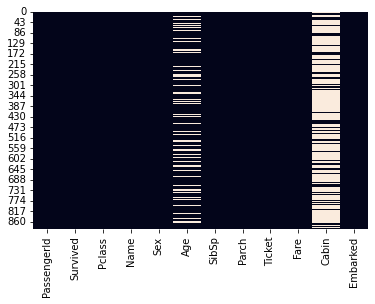

In [7]:
sns.heatmap(titanic_data.isnull(),cbar = False)

<AxesSubplot:xlabel='Survived', ylabel='count'>

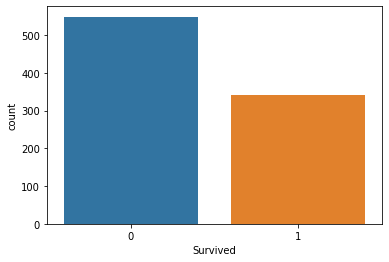

In [8]:
sns.countplot(x = 'Survived', data = titanic_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

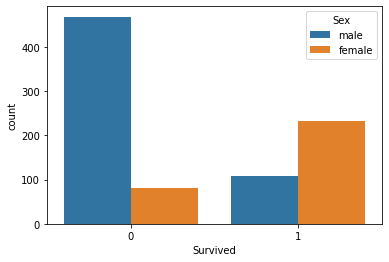

In [9]:
sns.countplot(x = 'Survived', hue = 'Sex', data = titanic_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

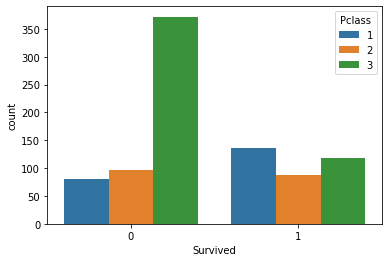

In [10]:
sns.countplot(x = 'Survived', hue = 'Pclass', data = titanic_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

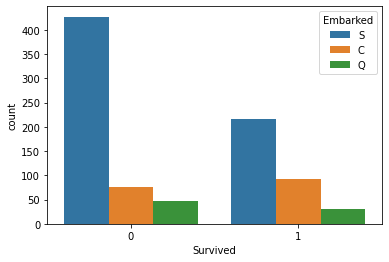

In [11]:
sns.countplot(x = 'Survived',hue  = 'Embarked', data = titanic_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

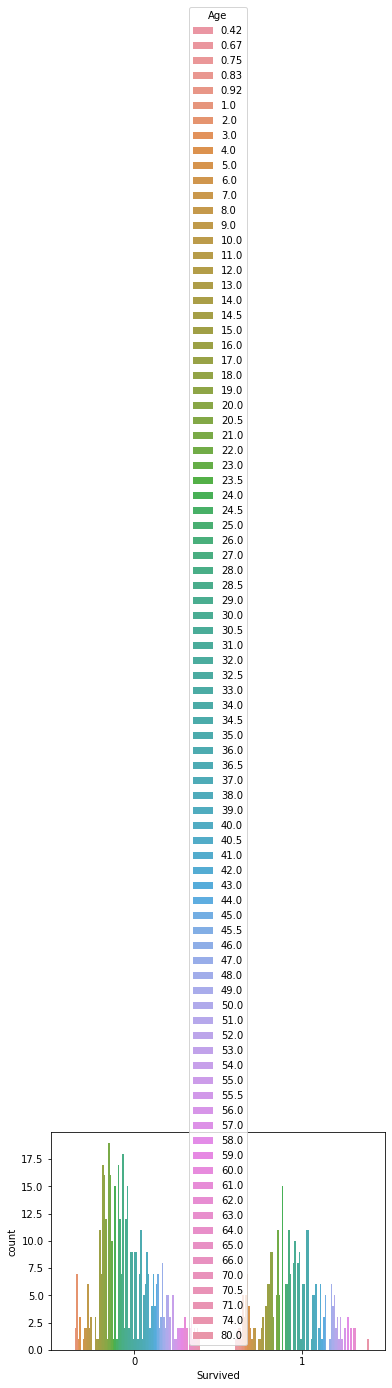

In [12]:
sns.countplot(x = 'Survived', hue = 'Age', data = titanic_data)

In [13]:
def add_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return titanic_data[titanic_data['Pclass']==1]['Age'].mean()
        elif Pclass == 2:
            return titanic_data[titanic_data['Pclass']==2]['Age'].mean()
        elif Pclass == 3:
            return titanic_data[titanic_data['Pclass']==3]['Age'].mean()
    else:
        return Age

In [14]:
titanic_data['Age'] = titanic_data[['Age','Pclass']].apply(add_age,axis = 1)
titanic_data['Age']

0      22.00000
1      38.00000
2      26.00000
3      35.00000
4      35.00000
         ...   
886    27.00000
887    19.00000
888    25.14062
889    26.00000
890    32.00000
Name: Age, Length: 891, dtype: float64

In [15]:
titanic_data.Sex = titanic_data.Sex.map({'female':0,'male':1})
titanic_data.Embarked  = titanic_data.Embarked.map({'S':0,'C':1,'Q':2,'nan':'NaN'})
titanic_data.Embarked

0      0
1      1
2      0
3      0
4      0
      ..
886    0
887    0
888    0
889    1
890    2
Name: Embarked, Length: 891, dtype: object

In [16]:
titanic_data.drop('Cabin',axis = 1,inplace = True)

In [17]:
titanic_data.dropna(inplace = True)

In [18]:
titanic_data.drop(['Name','PassengerId','Ticket'],axis = 1,inplace = True)

In [19]:
titanic_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.00000,1,0,7.2500,0
1,1,1,0,38.00000,1,0,71.2833,1
2,1,3,0,26.00000,0,0,7.9250,0
3,1,1,0,35.00000,1,0,53.1000,0
4,0,3,1,35.00000,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,1,27.00000,0,0,13.0000,0
887,1,1,0,19.00000,0,0,30.0000,0
888,0,3,0,25.14062,1,2,23.4500,0
889,1,1,1,26.00000,0,0,30.0000,1


In [20]:
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


In [21]:
x_data = titanic_data.drop('Survived',axis=1)
y_data = titanic_data['Survived']

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_training_data, x_test_data, y_training_data, y_test_data = train_test_split(x_data, y_data, test_size =0.2, random_state=0, stratify=y_data)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model = LogisticRegression()

In [26]:
model.fit(x_training_data, y_training_data)
predictions = model.predict(x_test_data)

In [27]:
from sklearn.metrics import classification_report

In [28]:
print(classification_report(y_test_data, predictions))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88       110
           1       0.81      0.79      0.80        68

    accuracy                           0.85       178
   macro avg       0.84      0.84      0.84       178
weighted avg       0.85      0.85      0.85       178



In [29]:
from sklearn.metrics import accuracy_score
print("Accuracy: ",accuracy_score(y_test_data, predictions))

Accuracy:  0.848314606741573


In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_data, predictions)
print(cm)

[[97 13]
 [14 54]]


<AxesSubplot:>

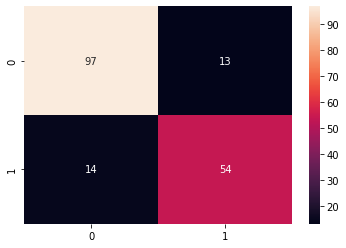

In [31]:
sns.heatmap(cm,annot = True)

In [32]:
titanic_test_data = pd.read_csv('../input/titanic/test.csv')

In [33]:
titanic_test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [34]:
titanic_test_data.shape

(418, 11)

In [35]:
titanic_test_data.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [36]:
titanic_test_data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<AxesSubplot:>

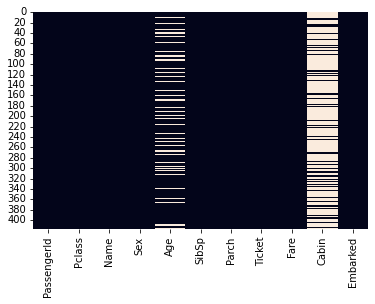

In [37]:
sns.heatmap(titanic_test_data.isnull(),cbar = False)

In [38]:
def add_fare(cols):
    Fare = cols[0]
    Pclass = cols[1]
    if pd.isnull(Fare):
        if Pclass == 1:
            return titanic_test_data[titanic_test_data['Pclass']==1]['Fare'].mean()
        elif Pclass == 2:
            return titanic_test_data[titanic_test_data['Pclass']==2]['Fare'].mean()
        elif Pclass == 3:
            return titanic_test_data[titanic_test_data['Pclass']==3]['Fare'].mean()
    else:
        return Fare

In [39]:
def add_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return titanic_test_data[titanic_test_data['Pclass']==1]['Age'].mean()
        elif Pclass == 2:
            return titanic_test_data[titanic_test_data['Pclass']==2]['Age'].mean()
        elif Pclass == 3:
            return titanic_test_data[titanic_test_data['Pclass']==3]['Age'].mean()
    else:
        return Age

In [40]:
titanic_test_data['Age'] = titanic_test_data[['Age','Pclass']].apply(add_age,axis = 1)
titanic_test_data['Age']

0      34.500000
1      47.000000
2      62.000000
3      27.000000
4      22.000000
         ...    
413    24.027945
414    39.000000
415    38.500000
416    24.027945
417    24.027945
Name: Age, Length: 418, dtype: float64

In [41]:
titanic_test_data['Fare'] = titanic_test_data[['Fare','Pclass']].apply(add_fare,axis = 1)
titanic_test_data['Fare']

0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

In [42]:
titanic_test_data.Sex = titanic_test_data.Sex.map({'female':0,'male':1})
titanic_test_data.Embarked  = titanic_test_data.Embarked.map({'S':0,'C':1,'Q':2,'nan':'NaN'})

In [43]:
titanic_test_data.drop('Cabin',axis = 1,inplace = True)

In [44]:
titanic_test_data.dropna(inplace = True)

In [45]:
titanic_test_data.drop(['Name','PassengerId','Ticket'],axis = 1,inplace = True)

In [46]:
titanic_test_data

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.500000,0,0,7.8292,2
1,3,0,47.000000,1,0,7.0000,0
2,2,1,62.000000,0,0,9.6875,2
3,3,1,27.000000,0,0,8.6625,0
4,3,0,22.000000,1,1,12.2875,0
...,...,...,...,...,...,...,...
413,3,1,24.027945,0,0,8.0500,0
414,1,0,39.000000,0,0,108.9000,1
415,3,1,38.500000,0,0,7.2500,0
416,3,1,24.027945,0,0,8.0500,0


In [47]:
titanic_test_data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,7.8292,2
1,3,0,47.0,1,0,7.0000,0
2,2,1,62.0,0,0,9.6875,2
3,3,1,27.0,0,0,8.6625,0
4,3,0,22.0,1,1,12.2875,0


In [48]:
titanic_test_data.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [49]:
titanic_test = pd.read_csv('../input/titanic/test.csv')

In [50]:
prediction=model.predict(titanic_test_data)

In [51]:
prediction

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,

In [52]:
submission = pd.DataFrame({
        "PassengerId": titanic_test["PassengerId"],
        "Survived": prediction
    })
submission.to_csv('submission.csv', index=False)
